In [129]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [130]:
data = pd.read_csv('diabetes.csv')
print(data.shape)

y = data['Outcome'].values  # Extract target
X = data.drop('Outcome', axis=1).values  # Extract features

# Add bias term (column of 1s)
bias = np.ones((X.shape[0], 1))
X = np.concatenate([X, bias], axis=1)  # Use concatenate, not concatanate

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

(768, 9)
X shape: (768, 9)
y shape: (768,)


In [131]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [132]:
from sklearn.preprocessing import StandardScaler

# scale features to same scale (standardization) and keep the bias column if present

# keep a copy of original X
X_orig = X.copy()

# detect & separate bias column (assumed constant 1s in last column)
if np.allclose(X[:, -1], 1.0):
    features, bias_col = X[:, :-1], X[:, -1:].copy()
else:
    features, bias_col = X, None

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# reconstruct X (preserve bias column if it existed)
if bias_col is not None:
    X = np.concatenate([features_scaled, bias_col], axis=1)
else:
    X = features_scaled

# quick sanity checks
print("X shape:", X.shape)
print("First row (scaled):", X[0])
print("Per-feature mean (approx 0):", np.round(np.mean(X[:, :features_scaled.shape[1]], axis=0), 6))
print("Per-feature std  (approx 1):", np.round(np.std(X[:, :features_scaled.shape[1]], axis=0), 6))

X shape: (768, 9)
First row (scaled): [ 0.63994726  0.84832379  0.14964075  0.90726993 -0.69289057  0.20401277
  0.46849198  1.4259954   1.        ]
Per-feature mean (approx 0): [-0. -0.  0.  0. -0.  0.  0.  0.]
Per-feature std  (approx 1): [1. 1. 1. 1. 1. 1. 1. 1.]


In [133]:
from sklearn.model_selection import train_test_split

# Split data into train and test (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set: X_train {X_train.shape}, y_train {y_train.shape}')
print(f'Test set: X_test {X_test.shape}, y_test {y_test.shape}')
print(f'Train class distribution: {np.bincount(y_train)}')
print(f'Test class distribution: {np.bincount(y_test)}')

Training set: X_train (614, 9), y_train (614,)
Test set: X_test (154, 9), y_test (154,)
Train class distribution: [400 214]
Test class distribution: [100  54]


In [134]:
# num_obs = 5000

# # Generate random x1 and x2 values between -1 and 1
# x1 = np.random.uniform(-1, 1, size=num_obs)
# x2 = np.random.uniform(-1, 1, size=num_obs)

# # Add bias term (column of 1s)
# bias = np.ones(num_obs)

# # Stack into feature matrix: [x1, x2, bias]
# X = np.column_stack([x1, x2, bias])

# # ============ CHOOSE ONE PATTERN BELOW ============

# # 1. Circle pattern (Easy)
# # y = (np.sqrt(x1**2 + x2**2) < 0.75).astype(int)

# # 2. XOR pattern (Medium - Classic non-linear)
# # y = ((x1 * x2) > 0).astype(int)

# # #3. Spiral pattern (Hard)
# # theta = np.arctan2(x2, x1)
# # r = np.sqrt(x1**2 + x2**2)
# # y = ((np.sin(theta * 3) * r) > 0).astype(int)

# # 4. Checkerboard pattern (Hard)
# y = (((x1 > 0) & (x2 > 0)) | ((x1 < 0) & (x2 < 0))).astype(int)

# # 5. Double circle (Medium)
# # r = np.sqrt(x1**2 + x2**2)
# # y = ((r < 0.4) | ((r > 0.6) & (r < 0.9))).astype(int)

# # 6. Four corners (Medium)
# # y = ((np.abs(x1) > 0.5) & (np.abs(x2) > 0.5)).astype(int)

# # 7. Heart shape (Hard)
# # y = ((x1**2 + (x2 - np.abs(x1)**0.5)**2) < 0.5).astype(int)

# # 8. Star pattern (Very Hard)
# # theta = np.arctan2(x2, x1)
# # r = np.sqrt(x1**2 + x2**2)
# # y = (r < (0.5 + 0.3 * np.cos(5 * theta))).astype(int)

# # 9. Sine wave boundary (Medium-Hard)
# # y = (x2 < np.sin(x1 * np.pi * 3) * 0.5).astype(int)

# # # 10. Complex multi-shape (Very Hard)
# # circle1 = (np.sqrt((x1 - 0.5)**2 + (x2 - 0.5)**2) < 0.3)
# # circle2 = (np.sqrt((x1 + 0.5)**2 + (x2 + 0.5)**2) < 0.3)
# # square = (np.abs(x1) < 0.3) & (np.abs(x2) < 0.3)
# # y = (circle1 | circle2 | square).astype(int)

# print(f'X shape: {X.shape}')
# print(f'y shape: {y.shape}')
# print(f'Class 0 (outside): {np.sum(y==0)} samples')
# print(f'Class 1 (inside): {np.sum(y==1)} samples')

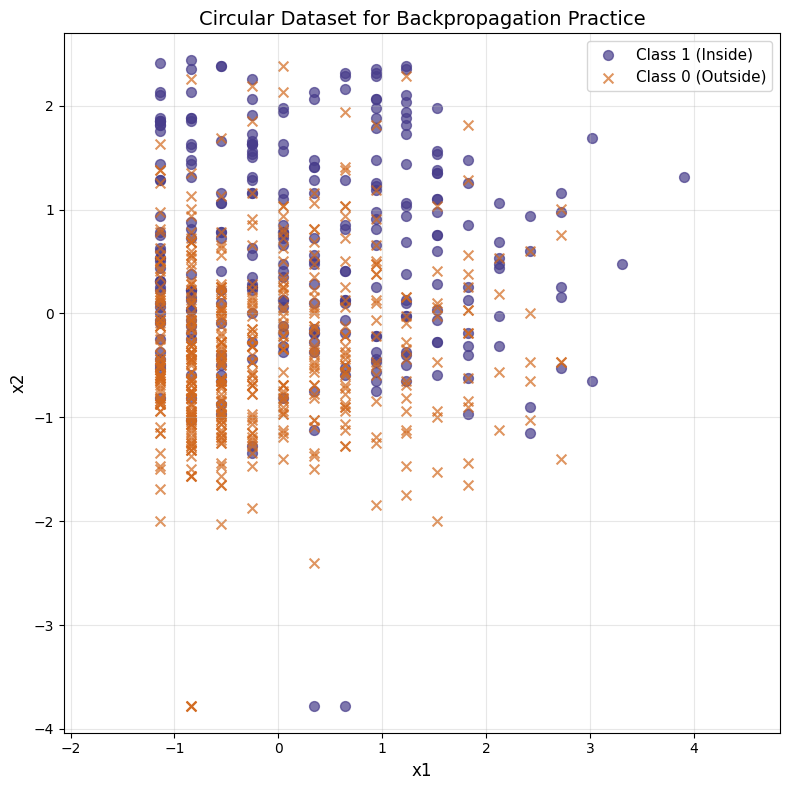

In [135]:
# Visualize the circular dataset
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(X[y==1, 0], X[y==1, 1], c='darkslateblue', marker='o', s=50, alpha=0.7, label='Class 1 (Inside)')
ax.scatter(X[y==0, 0], X[y==0, 1], c='chocolate', marker='x', s=50, alpha=0.7, label='Class 0 (Outside)')
ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_title('Circular Dataset for Backpropagation Practice', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.axis('equal')
plt.tight_layout()
plt.show()

Defining Sigmoid function

In [136]:
def sigmoid(x):
    return 1.0/(1.0 + np.exp(-x))

Defining loss funciton

In [137]:
def loss_func(y_true, y_pred, eps=1e-16):
    # Clip predictions to avoid log(0)
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -(np.sum(y_true * np.log(y_pred)) + np.sum((1-y_true) * np.log(1-y_pred))) / len(y_true)

Plottig loss and accuracy

In [138]:
def plot_loss_accuracy(loss_vals, accuracies):
    fig = plt.figure(figsize=(16, 8))
    fig.suptitle('Log Loss and Accuracy over iterations')
    
    ax = fig.add_subplot(1, 2, 1)
    ax.plot(loss_vals)
    ax.grid(True)
    ax.set(xlabel='iterations', title='Log Loss')
    
    ax = fig.add_subplot(1, 2, 2)
    ax.plot(accuracies)
    ax.grid(True)
    ax.set(xlabel='iterations', title='Accuracy');

Defining the forword passing function

In [139]:
def forward_pass_N_gradients(X_input, W1, W2, y_true):
    """Modified to accept X as parameter"""
    # Calculation for the first hidden layer
    Z_1 = np.dot(X_input, W1)
    a_1 = sigmoid(Z_1)
    
    # Calculation for the second hidden layer
    Z_2 = np.dot(a_1, W2)
    y_pred = sigmoid(Z_2)

    # Calculating gradients for W1 and W2
    grad_W2 = np.dot((-y_true + y_pred), a_1)
    
    # (-y_true + y)^.W2, shape (n, 1) · (1, num_nodes) = (n, num_nodes)
    temp_1 = np.dot((-y_true + y_pred).reshape(-1,1), W2.reshape(-1,1).T)
    
    # (1-a1)*a1, shape (n, num_nodes)
    temp_2 = (1-a_1) * a_1
    
    # Element-wise multiplication
    temp_1 = temp_1 * temp_2
    
    # Gradient for W1: X^T · temp_1
    grad_W1 = np.dot(X_input.T, temp_1)

    return y_pred, (grad_W1, grad_W2)

Taking random values for both(two) hidden layers' weights. 

In [140]:
def evaluate_model(X_data, y_data, W1, W2, dataset_name="Dataset"):
    """Evaluate model on given dataset"""
    # Forward pass only (no gradient calculation needed)
    Z_1 = np.dot(X_data, W1)
    a_1 = sigmoid(Z_1)
    Z_2 = np.dot(a_1, W2)
    y_pred = sigmoid(Z_2)
    
    # Calculate metrics
    loss = loss_func(y_data, y_pred)
    accuracy = np.sum((y_pred >= 0.5) == y_data) / len(y_data)
    
    # Detailed metrics
    pred_binary = (y_pred >= 0.5).astype(int)
    tp = np.sum((pred_binary == 1) & (y_data == 1))
    tn = np.sum((pred_binary == 0) & (y_data == 0))
    fp = np.sum((pred_binary == 1) & (y_data == 0))
    fn = np.sum((pred_binary == 0) & (y_data == 1))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\n{'='*60}")
    print(f"{dataset_name} Results:")
    print(f"{'='*60}")
    print(f"Loss: {loss:.6f}")
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1_score:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"True Positives:  {tp}")
    print(f"True Negatives:  {tn}")
    print(f"False Positives: {fp}")
    print(f"False Negatives: {fn}")
    print(f"{'='*60}\n")
    
    return y_pred, accuracy, loss

In [141]:
def plot_train_test_curves(train_loss, train_acc, test_loss, test_acc):
    """Plot training and testing curves"""
    fig = plt.figure(figsize=(18, 6))
    fig.suptitle('Training vs Testing Performance', fontsize=16, fontweight='bold')
    
    # Loss plot
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.plot(train_loss, label='Train Loss', linewidth=2)
    test_epochs = np.arange(0, len(train_loss), 100)[:len(test_loss)]
    ax1.plot(test_epochs, test_loss, label='Test Loss', linewidth=2, linestyle='--')
    ax1.set_xlabel('Iterations', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Loss Curve')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Accuracy plot
    ax2 = fig.add_subplot(1, 3, 2)
    ax2.plot(train_acc, label='Train Accuracy', linewidth=2)
    ax2.plot(test_epochs, test_acc, label='Test Accuracy', linewidth=2, linestyle='--')
    ax2.set_xlabel('Iterations', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.set_title('Accuracy Curve')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Overfitting detection
    ax3 = fig.add_subplot(1, 3, 3)
    if len(test_acc) > 0:
        gap = np.array(train_acc)[test_epochs[:len(test_acc)]] - np.array(test_acc)
        ax3.plot(test_epochs[:len(gap)], gap, color='red', linewidth=2)
        ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        ax3.set_xlabel('Iterations', fontsize=12)
        ax3.set_ylabel('Train Acc - Test Acc', fontsize=12)
        ax3.set_title('Overfitting Gap')
        ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [142]:
def back_propagation():
    print("Starting Training...")
    print("="*60)
    
    total_epoch = 3000
    learning_rate = 0.001
    num_of_nodes = 4
    
    # Initialize weights
    W1 = np.random.uniform(-1, 1, size=(X_train.shape[1], num_of_nodes))
    W2 = np.random.uniform(-1, 1, size=(num_of_nodes,))

    train_loss_vals, train_accuracies = [], []
    test_loss_vals, test_accuracies = [], []
    best_test_acc = 0
    best_epoch = 0
    
    for i in range(total_epoch):
        # Training step
        y_pred_train, (grad_W1, grad_W2) = forward_pass_N_gradients(X_train, W1, W2, y_train)
        train_loss = loss_func(y_train, y_pred_train)
        train_acc = np.sum((y_pred_train >= 0.5) == y_train) / len(y_train)
        
        train_loss_vals.append(train_loss)
        train_accuracies.append(train_acc)
        
        # Update weights
        W1 = W1 - learning_rate * grad_W1
        W2 = W2 - learning_rate * grad_W2
        
        # Evaluate on test set (every 100 epochs)
        if i % 100 == 0:
            y_pred_test, (_, _) = forward_pass_N_gradients(X_test, W1, W2, y_test)
            test_loss = loss_func(y_test, y_pred_test)
            test_acc = np.sum((y_pred_test >= 0.5) == y_test) / len(y_test)
            
            test_loss_vals.append(test_loss)
            test_accuracies.append(test_acc)
            
            if test_acc > best_test_acc:
                best_test_acc = test_acc
                best_epoch = i
        
        # Print progress
        if (i % 5000) == 0:
            print(f'Epoch {i:5d} | Train Loss: {train_loss:.6f} | Train Acc: {train_acc:.4f}')
    
    print(f"\nTraining Complete!")
    print(f"Best Test Accuracy: {best_test_acc:.4f} at Epoch {best_epoch}")
    
    # Plot training curves
    plot_train_test_curves(train_loss_vals, train_accuracies, test_loss_vals, test_accuracies)
    
    # Final evaluation on both sets
    y_pred_train_final, train_acc_final, train_loss_final = evaluate_model(X_train, y_train, W1, W2, "TRAINING SET")
    y_pred_test_final, test_acc_final, test_loss_final = evaluate_model(X_test, y_test, W1, W2, "TEST SET")
    
    return W1, W2, y_pred_train_final, y_pred_test_final

In [143]:
def visualize_predictions(y_pred, y_true, X):
    """
    Visualize the predictions vs ground truth
    """
    # Convert predictions to binary (0 or 1)
    pred_binary = (y_pred >= 0.5).astype(int)
    
    # Create prediction masks
    correct_class1 = (pred_binary == 1) & (y_true == 1)  # True positives
    correct_class0 = (pred_binary == 0) & (y_true == 0)  # True negatives
    wrong_class1 = (pred_binary == 1) & (y_true == 0)    # False positives
    wrong_class0 = (pred_binary == 0) & (y_true == 1)    # False negatives
    
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Plot correct predictions
    ax.scatter(X[correct_class1, 0], X[correct_class1, 1], 
               c='darkslateblue', marker='o', s=50, alpha=0.7, 
               label=f'True Positives ({np.sum(correct_class1)})')
    ax.scatter(X[correct_class0, 0], X[correct_class0, 1], 
               c='chocolate', marker='x', s=50, alpha=0.7, 
               label=f'True Negatives ({np.sum(correct_class0)})')
    
    # Plot incorrect predictions with larger markers
    if np.sum(wrong_class1) > 0:
        ax.scatter(X[wrong_class1, 0], X[wrong_class1, 1], 
                   c='red', marker='s', s=150, alpha=0.6, 
                   edgecolors='black', linewidths=2,
                   label=f'False Positives ({np.sum(wrong_class1)})')
    if np.sum(wrong_class0) > 0:
        ax.scatter(X[wrong_class0, 0], X[wrong_class0, 1], 
                   c='yellow', marker='D', s=150, alpha=0.6, 
                   edgecolors='black', linewidths=2,
                   label=f'False Negatives ({np.sum(wrong_class0)})')
    
    ax.set_xlabel('x1', fontsize=12)
    ax.set_ylabel('x2', fontsize=12)
    ax.set_title('Neural Network Predictions vs Ground Truth', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11, loc='best')
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    plt.tight_layout()
    plt.show()

Starting Training...
Epoch     0 | Train Loss: 0.875419 | Train Acc: 0.3176

Training Complete!
Best Test Accuracy: 0.7403 at Epoch 100


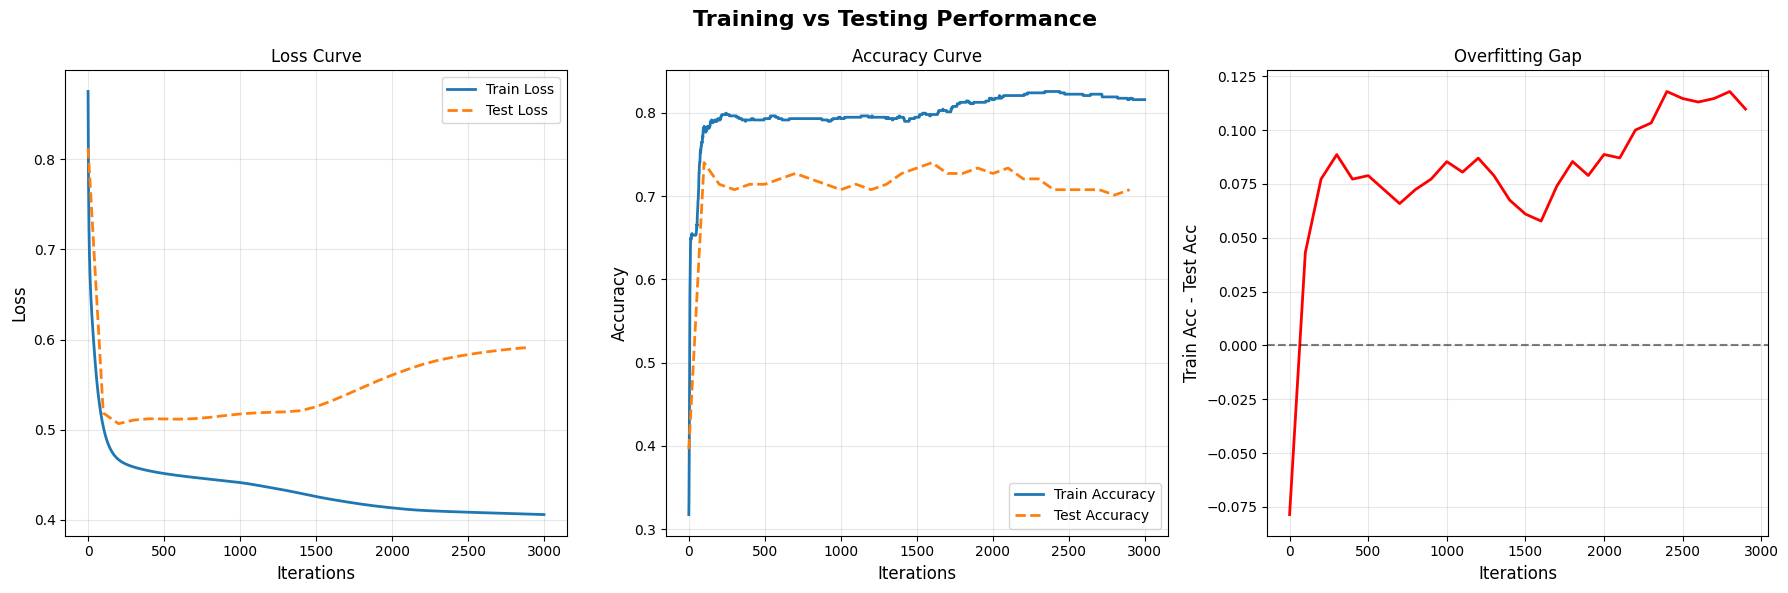


TRAINING SET Results:
Loss: 0.405706
Accuracy: 0.8160 (81.60%)
Precision: 0.7644
Recall: 0.6822
F1-Score: 0.7210

Confusion Matrix:
True Positives:  146
True Negatives:  355
False Positives: 45
False Negatives: 68


TEST SET Results:
Loss: 0.592564
Accuracy: 0.7143 (71.43%)
Precision: 0.6000
Recall: 0.5556
F1-Score: 0.5769

Confusion Matrix:
True Positives:  30
True Negatives:  80
False Positives: 20
False Negatives: 24


Visualizing Training Set Predictions:


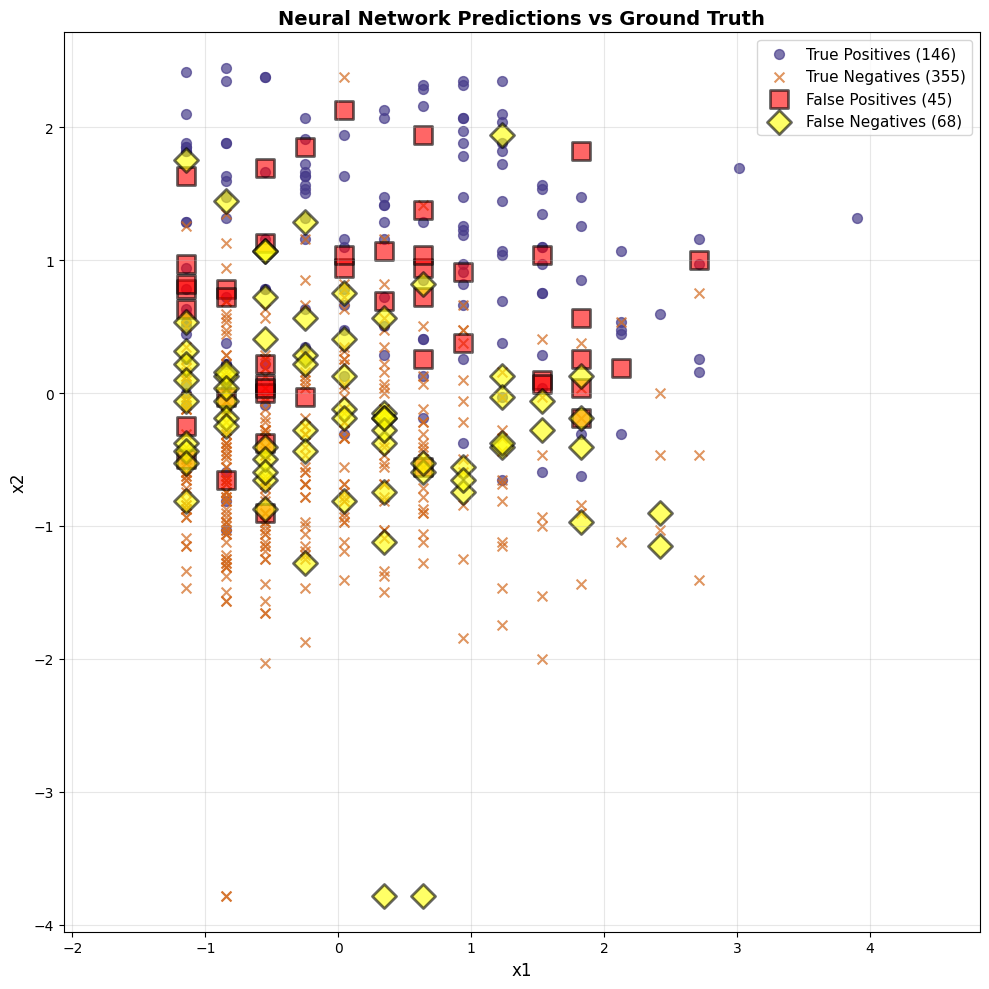


Visualizing Test Set Predictions:


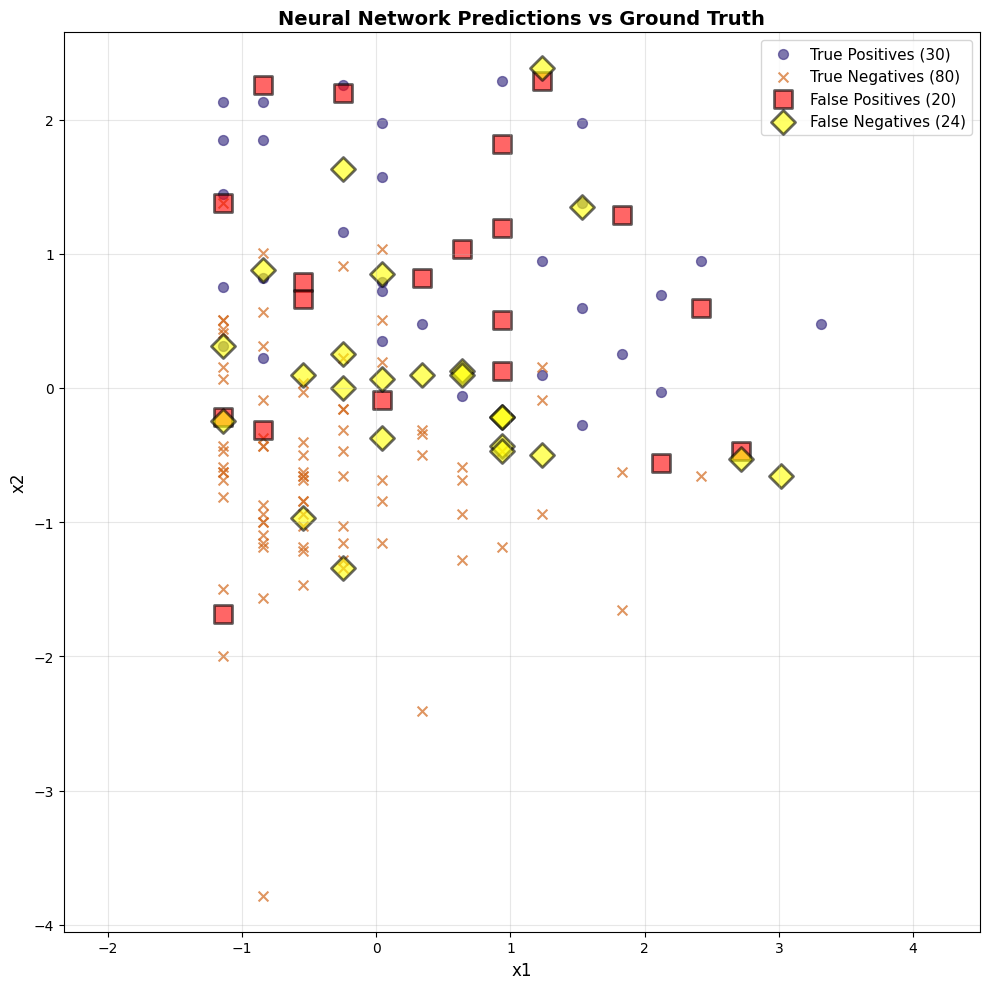

In [144]:
# Run training and evaluation
W1, W2, y_pred_train, y_pred_test = back_propagation()

# Visualize predictions on both datasets
print("\nVisualizing Training Set Predictions:")
visualize_predictions(y_pred_train, y_train, X_train)

print("\nVisualizing Test Set Predictions:")
visualize_predictions(y_pred_test, y_test, X_test)